# imports

In [38]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Strategies_Evolution import * # Import strategies, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 

In [39]:
# Flow
Grad = StrainStresslet
# Data
NPoints = 3 # Grid number of points per axis
NTrials = 300 # Number of trial x point

Duration = 2000
AntennaeLength = .0001 # Sensors distance, on antennae
angles = np.array([np.pi/3, np.pi/4, np.pi/6]) # x axis
AgentPositions =  np.array([np.cos(angles), np.sin(angles), np.zeros(len(angles))]).T
print(AgentPositions)
e3 = np.array([1.0, 0.0, 0.0]) # Source flow axis of symmetry, scheme zxy
dt = .1 # Timesteps 
roll = .2 # Roll Intensity
V = 0
NameStrategies = ["T"] #_not", "T", "I"] 

# Results
t_T_end = np.zeros((NPoints, NTrials, 3))
t_T_end_timepoints = np.zeros((NPoints, NTrials, Duration, 3))

a1 = np.zeros((NPoints, NTrials))
a2 = np.zeros((NPoints, NTrials))

[[0.5        0.8660254  0.        ]
 [0.70710678 0.70710678 0.        ]
 [0.8660254  0.5        0.        ]]


In [41]:
# tensor gradient in coordinates xyz
def Define_a1a2_strain_eigenvectors(Grad, e3, AgentPosition):
    G = Grad(e3, AgentPosition)
    assert np.isclose(np.trace(G), 0), "gradient is not trace free"
    #assert np.allclose(G, np.transpose(G)), "gradient is not symmetric"
    G_skew = 0.5 * (G - G.T)
    
    # calculations of eigenvectors and relative eigenvalue a
    vaps, veps = np.linalg.eig(G[:-1,:-1])
    
    i_max = np.argmax(np.abs(vaps))
    s = np.sum(vaps) / vaps[i_max] - 1
    lambda_tilde = vaps[1-i_max]/vaps[i_max]
    
    if lambda_tilde > 0:
        lambda_tilde *= -1
        
    omega = 0.0 # G_skew[G_skew != 0][0]/vaps[i_max]
    
    a1 = np.sqrt(lambda_tilde/(lambda_tilde-1))
    a2 = np.sqrt((lambda_tilde + lambda_tilde**2)/(lambda_tilde**2+2*lambda_tilde+omega**2))
    
    return a1, a2



In [42]:
for a_index, AgentPosition in enumerate(AgentPositions):
    for trials_i in range(NTrials):
        # Random orientation of agent axis
        alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
        R = Rotation(alpha, np.abs(beta), gamma)
        n_T = np.dot(R,[0, 1, 0])
        b_T = np.dot(R,[0, 0, 1])
        t_T = np.dot(R,[1, 0, 0])

        n_T_noroll = np.dot(R, [0, 1, 0])
        b_T_noroll = np.dot(R, [0, 0, 1])
        t_T_noroll = np.dot(R, [1, 0, 0])
        
        for time in range(Duration):
            n_T, b_T, t_T, _ = Evolution_Triangulation(n_T, b_T, t_T, AntennaeLength, AgentPosition, Grad, e3, dt, V, roll)
            n_T_noroll, b_T_noroll, t_T_noroll, _ = Evolution_Triangulation(n_T_noroll, b_T_noroll, t_T_noroll, AntennaeLength, AgentPosition, Grad, e3, dt, V, 0.0)
            t_T_end_timepoints[a_index, trials_i, time, :] = t_T.copy()
            
        t_T_end[a_index, trials_i, :] = t_T.copy()
        a1[a_index, trials_i], a2[a_index, trials_i] = Define_a1a2_strain_eigenvectors(Grad, e3, AgentPosition)
        
        

# Project t in the eigenbasis of G

In [43]:
# t_T_end shape: (NPoints, NTrials, NTimesteps, 3)

num_a, num_trials, num_timesteps, _ = t_T_end_timepoints.shape

# Allocate array for t in eigenbasis
t_eig = np.zeros_like(t_T_end)
t_eig_time = np.zeros_like(t_T_end_timepoints)
AgentPosition_eig = np.zeros_like(AgentPositions)
P_Theory = np.zeros(len(AgentPositions))
for a_index in range(num_a):
    AgentPosition = agent_positions[a_index]

    # Compute gradient and eigenbasis
    G = Grad(e3, AgentPosition)
    eigvals, eigvecs = np.linalg.eigh(G)

    # sort indices by descending absolute eigenvalue
    idx = np.argsort(np.abs(eigvals))[::-1]
    
    # reorder eigenvalues and eigenvectors
    eigvals_sorted = eigvals[idx]
    eigvecs_sorted = eigvecs[:, idx]

    t_eig[a_index] = t_T_end[a_index] @ eigvecs_sorted
    t_eig_time[a_index] = t_T_end_timepoints[a_index] @ eigvecs_sorted

# plots

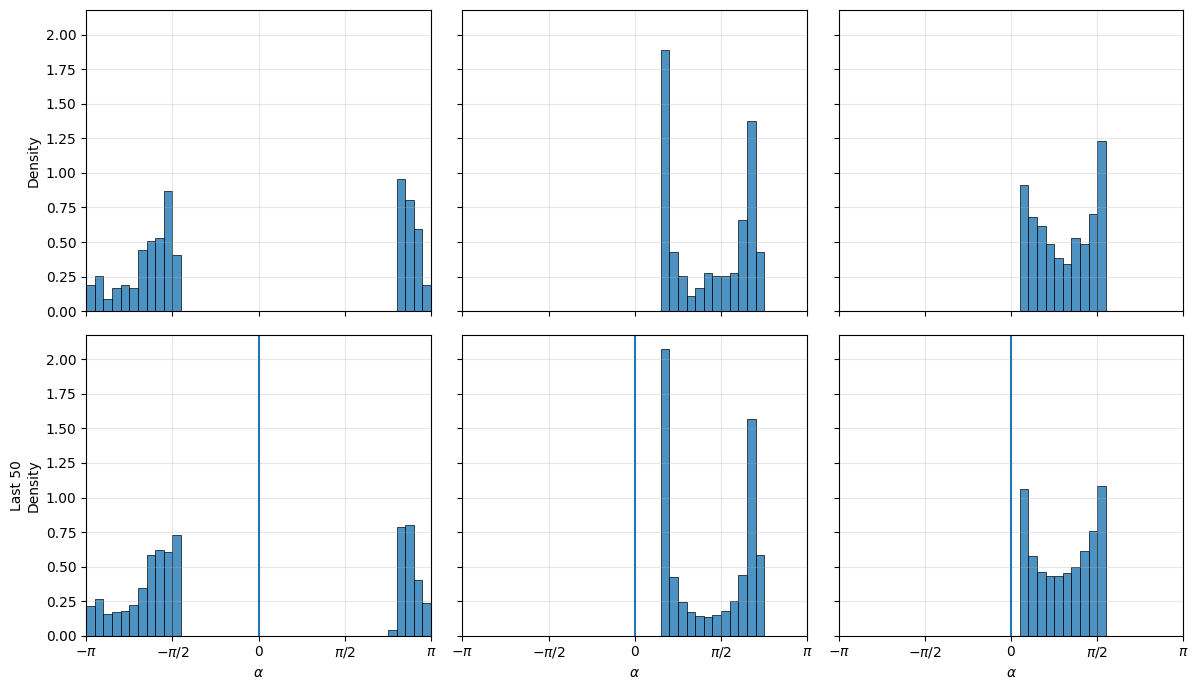

In [44]:
# Number of last timesteps to include
NTIMEPOINTS = 50 

# Extract components (keep time!)
t2 = t_eig_time[:, :, :, 1]  
t3 = t_eig_time[:, :, :, 2]

# Compute angle for all timepoints
theta = np.arctan2(
    t3 * a2[..., np.newaxis],
    t2 * a1[..., np.newaxis]
)
num_a = t_eig_time.shape[0]

# Which a_index values to plot
a_indices = [0, 1, 2]

nbins = 40
angle_min, angle_max = -np.pi, np.pi
bins = np.linspace(angle_min, angle_max, nbins + 1)

# 2 rows: endpoint (top), last NTIMEPOINTS (bottom)
fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 7),
    sharex=True,
    sharey=True
)

for col, a_index in enumerate(a_indices):

    # ---------- TOP ROW: endpoint only ----------
    angles_end = theta[a_index, :, -1]   # last timestep
    angles_end = angles_end[np.isfinite(angles_end)]

    if angles_end.size > 0:
        axes[0, col].hist(
            angles_end,
            bins=bins,
            density=True,
            alpha=0.8,
            edgecolor='black',
            linewidth=0.6
        )

    axes[0, col].set_xlim(angle_min, angle_max)
    axes[0, col].grid(True, alpha=0.3)

    # ---------- BOTTOM ROW: last NTIMEPOINTS ----------
    angles_tail = theta[a_index, :, -NTIMEPOINTS:]  # shape (NTrials, NTIMEPOINTS)
    angles_tail = angles_tail.ravel()
    angles_tail = angles_tail[np.isfinite(angles_tail)]

    if angles_tail.size > 0:
        axes[1, col].hist(
            angles_tail,
            bins=bins,
            density=True,
            alpha=0.8,
            edgecolor='black',
            linewidth=0.6
        )
    axes[1, col].axvline(x = P_Theory[a_index])
    axes[1, col].set_xlim(angle_min, angle_max)
    axes[1, col].grid(True, alpha=0.3)

# ---------- Shared formatting ----------
for ax in axes[-1]:
    ax.set_xlabel(r'$\alpha$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels(
        [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']
    )

axes[0, 0].set_ylabel('Density')
axes[1, 0].set_ylabel(f'Last {NTIMEPOINTS}\nDensity')

plt.tight_layout()
plt.savefig('./DistributionAnglesTimePoints.png', dpi=300)
plt.show()
